# Var

In [1]:
work_dir = ".."
samples <- c("MC1")

In [2]:
library(dplyr)
library(ggplot2)
library(LeyLabRMisc)
library(data.table)
library(tidyverse)
library(pROC)
library(PRROC)
library(ComplexHeatmap)
library(circlize)
library(Biostrings)
library(scales)
library(boot)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“replacing previous import ‘data.table::last’ by ‘tidytable::last’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::first’ by ‘tidytable::first’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::between’ by ‘tidytable::between’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::%notin%’ by ‘tidytable::%notin%’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘data.table::fread’ by ‘tidytable::fread’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::fread’ by ‘data.table::fread’ when loading ‘LeyLabRMisc’”
Warning message:
“replacing previous import ‘tidytable::distinct’ by ‘dplyr::distinct’ when loading ‘LeyLabRM

In [3]:
# limit the size of output tables
df.dims(6)

# Load

## Contacts

In [4]:
# Load list with all the contacts between contigs (normalized intensities)
all_contacts <- fread(file.path(work_dir, "data/stool/Normalized_all_contacts_list.tsv"), sep = "\t")
colnames(all_contacts) <- c("index1","index2","contacts")
all_contacts

index1,index2,contacts
<chr>,<chr>,<dbl>
contig_1,contig_1000,355.456
contig_1,contig_10000,0.000
contig_1,contig_10002,0.000
⋮,⋮,⋮
contig_circular_6,contig_circular_7,0
contig_circular_6,contig_circular_8,0
contig_circular_7,contig_circular_8,0


## Contig-bin association

In [5]:
# Load asociation of contigs to bins
bins <- fread(file.path(work_dir, "data/stool/bins_DASTool_contig2bin.tsv"), sep = "\t", header = F)

# Remove the 'X__' part from the first column
bins$V1 <- str_replace(bins$V1, "^[^_]+__", "")

# Rename the columns
colnames(bins) <- c('contig', 'bin')#, 'sample')
bins

contig,bin
<chr>,<chr>
contig_13093,MetaCC_bin_0200
contig_13094,MetaCC_bin_0200
contig_1997,MetaCC_bin_0200
⋮,⋮
contig_8563,ImputeCC_bin_0128
contig_9402,ImputeCC_bin_0128
contig_9876,ImputeCC_bin_0128


## Bins quality

In [6]:
# Load quality of bns
bins_quality <- fread(file.path(work_dir, "data/stool/quality_report.tsv"), sep = "\t", header = T)
bins_quality

Name,Completeness,Contamination,Completeness_Model_Used,Translation_Table_Used,Coding_Density,Contig_N50,Average_Gene_Length,Genome_Size,GC_Content,Total_Coding_Sequences,Additional_Notes
<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<chr>
ImputeCC_bin_0011,99.99,1.08,Neural Network (Specific Model),11,0.886,400703,313.5842,3435960,0.42,3244,None
ImputeCC_bin_0012,97.23,1.80,Gradient Boost (General Model),11,0.864,386709,320.4316,2530848,0.52,2280,None
ImputeCC_bin_0013,98.06,1.38,Neural Network (Specific Model),11,0.883,317249,340.9270,3118299,0.54,2697,None
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
semibin2_bin_95_sub,99.96,11.15,Neural Network (Specific Model),11,0.827,185651,317.9054,3271128,0.55,2843,None
semibin2_bin_97,93.42,3.07,Gradient Boost (General Model),11,0.878,160988,301.5918,2755756,0.56,2680,None
semibin2_bin_99,93.32,0.73,Gradient Boost (General Model),11,0.877,361821,314.8360,2341559,0.60,2177,None


## Taxa

In [7]:
# Import the taxonomic classification of the bins from GTDBTK
tax_levs <- c('Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species')
tax = fread(file.path(work_dir, "data/stool/gtdbtk_summary_wTaxid.tsv")) %>%
  select(-starts_with('other_'), -note) %>%
  mutate(classification = gsub('^d__', '', classification),
         classification = gsub(';[pcofgs]__', ';', classification)) %>%
  separate(classification, tax_levs, sep = ';') %>%
  mutate(across(all_of(tax_levs), ~ifelse((. == '' | is.na(.)), 'unclassified', .)))
tax$sample <- "MC1"
tax

user_genome,Domain,Phylum,Class,Order,Family,Genus,Species,fastani_reference,fastani_reference_radius,⋯,closest_placement_af,pplacer_taxonomy,classification_method,msa_percent,translation_table,red_value,warnings,taxid,taxid_rank,sample
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>,<int64>,<chr>,<chr>
ImputeCC_bin_0011,Bacteria,Firmicutes_A,Clostridia,Lachnospirales,Lachnospiraceae,Mediterraneibacter,Mediterraneibacter torques,GCF_000153925.1,95.0,⋯,0.89,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Mediterraneibacter;s__,taxonomic classification defined by topology and ANI,95.75,11,N/A,N/A,3907049719,species,MC1
ImputeCC_bin_0012,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,CAG-272,UMGS1312,UMGS1312 sp900550625,GCA_900550625.1,95.0,⋯,0.96,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__UMGS1312;s__,taxonomic classification defined by topology and ANI,95.85,11,N/A,N/A,3803871039,species,MC1
ImputeCC_bin_0013,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Rikenellaceae,Alistipes_A,Alistipes_A pullistercoris,GCF_009557455.1,95.0,⋯,0.93,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Rikenellaceae;g__Alistipes_A;s__,taxonomic classification defined by topology and ANI,94.34,11,N/A,N/A,626865341,species,MC1
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
semibin2_bin_95_sub,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Ruminococcaceae,Gemmiger,Gemmiger qucibialis,GCF_003324125.1,95.0,⋯,0.71,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Gemmiger;s__,taxonomic classification defined by topology and ANI,92.30,11,N/A,N/A,3446184927,species,MC1
semibin2_bin_97,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Oscillospiraceae,CAG-170,CAG-170 sp900545925,GCA_900545925.1,95.0,⋯,0.82,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__CAG-170;s__,taxonomic classification defined by topology and ANI,83.20,11,N/A,N/A,3718831264,species,MC1
semibin2_bin_99,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Oscillospiraceae,CAG-83,CAG-83 sp900545585,GCA_900545585.1,95.0,⋯,0.86,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__CAG-83;s__,taxonomic classification defined by topology and ANI,87.55,11,N/A,N/A,2460402716,species,MC1


## Plasmids

In [9]:
plasmid_circular <- fread(file.path(work_dir, "data/stool/plasmids.tsv"), sep = "\t")
plasmid_circular

Contig,Prediction,Length,Sample
<chr>,<chr>,<int>,<chr>
contig_circular_0,plasmid_circular,7552,MC1
contig_circular_1,plasmid_circular,5576,MC1
contig_circular_2,plasmid_circular,5424,MC1
⋮,⋮,⋮,⋮
contig_circular_6,plasmid_circular,6398,MC1
contig_circular_7,plasmid_circular,5331,MC1
contig_circular_8,plasmid_circular,4203,MC1


# Data processing

## Contacts

In [10]:
# Filter low quality bins
bins_quality_filtered <- bins_quality %>%
    filter(Completeness >= 90 & Contamination <= 5) 
bins_quality_filtered

Name,Completeness,Contamination,Completeness_Model_Used,Translation_Table_Used,Coding_Density,Contig_N50,Average_Gene_Length,Genome_Size,GC_Content,Total_Coding_Sequences,Additional_Notes
<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<chr>
ImputeCC_bin_0011,99.99,1.08,Neural Network (Specific Model),11,0.886,400703,313.5842,3435960,0.42,3244,None
ImputeCC_bin_0012,97.23,1.80,Gradient Boost (General Model),11,0.864,386709,320.4316,2530848,0.52,2280,None
ImputeCC_bin_0013,98.06,1.38,Neural Network (Specific Model),11,0.883,317249,340.9270,3118299,0.54,2697,None
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
semibin2_bin_94,94.46,0.32,Gradient Boost (General Model),11,0.855,547702,303.8003,2253510,0.57,2118,None
semibin2_bin_97,93.42,3.07,Gradient Boost (General Model),11,0.878,160988,301.5918,2755756,0.56,2680,None
semibin2_bin_99,93.32,0.73,Gradient Boost (General Model),11,0.877,361821,314.8360,2341559,0.60,2177,None


In [11]:
bins <- bins %>%
    filter(bin %in% bins_quality_filtered$Name) 
bins

contig,bin
<chr>,<chr>
contig_13093,MetaCC_bin_0200
contig_13094,MetaCC_bin_0200
contig_1997,MetaCC_bin_0200
⋮,⋮
contig_6962,semibin2_bin_121
contig_7225,semibin2_bin_121
contig_9949,semibin2_bin_121


In [12]:
# Filter the contacts to exclude the ones that involve circular plasmids
contacts <- list()
for (i in samples){
  plasmid_circular_filtered <- plasmid_circular[plasmid_circular$Sample == i,]
  contacts[[i]] <- all_contacts %>%
    filter(!(index1 %in% plasmid_circular_filtered$Contig | index2 %in% plasmid_circular_filtered$Contig)) %>%
    mutate(
    index1_in_plasmids = if_else(index1 %in% plasmid_circular_filtered$Contig, TRUE, FALSE),
    index2_in_plasmids = if_else(index2 %in% plasmid_circular_filtered$Contig, TRUE, FALSE)
  )
}
contacts
joined_contacts <- rbind(contacts[[1]])

index1,index2,contacts,index1_in_plasmids,index2_in_plasmids
<chr>,<chr>,<dbl>,<lgl>,<lgl>
contig_1,contig_1000,355.456,FALSE,FALSE
contig_1,contig_10000,0.000,FALSE,FALSE
contig_1,contig_10002,0.000,FALSE,FALSE
⋮,⋮,⋮,⋮,⋮
contig_9996,contig_9997,98390.55,FALSE,FALSE
contig_9996,contig_9999,0.00,FALSE,FALSE
contig_9997,contig_9999,0.00,FALSE,FALSE


In [13]:
# Symmetrize contact table
contact_sym <- joined_contacts %>%
  dplyr::rename(x = index1, y = index2) %>%
  bind_rows(joined_contacts %>% dplyr::rename(x = index2, y = index1))
contact_sym

x,y,contacts,index1_in_plasmids,index2_in_plasmids
<chr>,<chr>,<dbl>,<lgl>,<lgl>
contig_1,contig_1000,355.456,FALSE,FALSE
contig_1,contig_10000,0.000,FALSE,FALSE
contig_1,contig_10002,0.000,FALSE,FALSE
⋮,⋮,⋮,⋮,⋮
contig_9997,contig_9996,98390.55,FALSE,FALSE
contig_9999,contig_9996,0.00,FALSE,FALSE
contig_9999,contig_9997,0.00,FALSE,FALSE


In [14]:
# Add bin information
contacts_bins <- contact_sym %>%
  left_join(bins, by = c("x" = "contig")) %>%
  dplyr::rename(binx = bin) %>%
  left_join(bins, by = c("y" = "contig")) %>%
  dplyr::rename(biny = bin) %>%
  filter(!is.na(binx), !is.na(biny))
contacts_bins

x,y,contacts,index1_in_plasmids,index2_in_plasmids,binx,biny
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_1,contig_1000,355.456,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10009,241.477,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0139
contig_1,contig_10011,0.000,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0047
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_9996,contig_9994,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,semibin2_bin_77
contig_9997,contig_9994,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,semibin2_bin_77
contig_9997,contig_9996,98390.55,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0022_sub


In [15]:
# Create heatmaps and orders per sample
heatmaps <- list()
orders <- list()

for (s in samples) {
  orders[[s]] <- bins %>%
    arrange(bin, contig) %>%
    pull(contig)

  heatmaps[[s]] <- contacts_bins %>%
    mutate(
      x = factor(x, levels = orders[[s]]),
      y = factor(y, levels = orders[[s]])
    )
}

heatmaps

x,y,contacts,index1_in_plasmids,index2_in_plasmids,binx,biny
<fct>,<fct>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_1,contig_1000,355.456,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10009,241.477,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0139
contig_1,contig_10011,0.000,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0047
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_9996,contig_9994,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,semibin2_bin_77
contig_9997,contig_9994,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,semibin2_bin_77
contig_9997,contig_9996,98390.55,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0022_sub


In [16]:
# Function to generate heatmap matrix
make_heatmap_matrix <- function(df, contig_order) {
  df %>%
    mutate(x = as.character(x), y = as.character(y)) %>%
    select(x, y, contacts) %>%
    pivot_wider(names_from = x, values_from = contacts, values_fill = 0) %>%
    column_to_rownames("y") %>%
    as.matrix() %>%
    { .[contig_order[contig_order %in% rownames(.)], contig_order[contig_order %in% colnames(.)]] }
}

get_min_nonzero <- function(mat) {
  min(mat[mat > 0])
}

In [17]:
# Get the contig and bin association into the table with all the contacts
# Merge all_contacts with bins to get bin1
joined_contacts <- merge(joined_contacts, bins, by.x = c("index1"), by.y = c("contig"), all.x = TRUE)
setnames(joined_contacts, "bin", "bin1")
# Merge all_contacts with bins to get bin2
joined_contacts <- merge(joined_contacts, bins, by.x = c("index2"), by.y = c("contig"), all.x = TRUE)
setnames(joined_contacts, "bin", "bin2")
# Reorder columns to desired order
joined_contacts <- joined_contacts[, .(index1, index2, contacts, bin1, bin2)]
joined_contacts

index1,index2,contacts,bin1,bin2
<chr>,<chr>,<dbl>,<chr>,<chr>
contig_1,contig_1000,355.456,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10000,0.000,semibin2_bin_61_sub,NA
contig_1000,contig_10000,0.000,MetaCC_bin_0170,NA
⋮,⋮,⋮,⋮,⋮
contig_9995,contig_9999,0,NA,NA
contig_9996,contig_9999,0,ImputeCC_bin_0022_sub,NA
contig_9997,contig_9999,0,ImputeCC_bin_0022_sub,NA


In [18]:
# Generate tables that contain contacts between the same MAG and different MAGs
all_contacts_no_NA <- joined_contacts[!(is.na(joined_contacts$bin1)|is.na(joined_contacts$bin2)),]
intra_contacts <- all_contacts_no_NA[all_contacts_no_NA$bin1 == all_contacts_no_NA$bin2,]
inter_contacts <- all_contacts_no_NA[all_contacts_no_NA$bin1 != all_contacts_no_NA$bin2,]
intra_contacts
inter_contacts

index1,index2,contacts,bin1,bin2
<chr>,<chr>,<dbl>,<chr>,<chr>
contig_10130,contig_10140,0.00,ImputeCC_bin_0149,ImputeCC_bin_0149
contig_10035,contig_10141,257213.42,ImputeCC_bin_0023,ImputeCC_bin_0023
contig_10036,contig_10142,74332.44,ImputeCC_bin_0111,ImputeCC_bin_0111
⋮,⋮,⋮,⋮,⋮
contig_9791,contig_9997,28968.61,ImputeCC_bin_0022_sub,ImputeCC_bin_0022_sub
contig_9792,contig_9997,44080.86,ImputeCC_bin_0022_sub,ImputeCC_bin_0022_sub
contig_9996,contig_9997,98390.55,ImputeCC_bin_0022_sub,ImputeCC_bin_0022_sub


index1,index2,contacts,bin1,bin2
<chr>,<chr>,<dbl>,<chr>,<chr>
contig_1,contig_1000,355.456,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10009,241.477,semibin2_bin_61_sub,MetaCC_bin_0139
contig_1000,contig_10009,0.000,MetaCC_bin_0170,MetaCC_bin_0139
⋮,⋮,⋮,⋮,⋮
contig_9962,contig_9997,324.9,ImputeCC_bin_0013,ImputeCC_bin_0022_sub
contig_9993,contig_9997,0.0,ImputeCC_bin_0111,ImputeCC_bin_0022_sub
contig_9994,contig_9997,0.0,semibin2_bin_77,ImputeCC_bin_0022_sub


In [19]:
# Calculation of PR curves
# Convert Contact_Type to binary labels
combined_contacts_roc <- bind_rows(mutate(intra_contacts, Contact_Type = "within same MAG"),
                               mutate(inter_contacts, Contact_Type = "Between different MAGs"))
combined_contacts_roc$Contact_Label <- ifelse(combined_contacts_roc$Contact_Type == "within same MAG", 1, 0)

pr_list <- list()
threshold_list <- list()
auc_table <- data.frame(row.names = c("AUC Integral", "Random AUC"))

for (s in samples) {
  # Subset data by sample
  sample_data <- subset(combined_contacts_roc)#, sample == s)
  
  # Calculate the Precision-Recall curve
  pr_obj <- pr.curve(scores.class0 = sample_data$contacts, weights.class0 = sample_data$Contact_Label, curve = TRUE , 
  rand.compute = TRUE,  max.compute = TRUE, min.compute = TRUE)
  print(pr_obj)
  
  # Store the PR curve object
  pr_list[[s]] <- pr_obj
  
  # Extract precision, recall, and thresholds
  recalls <- pr_obj$curve[, 1]
  precisions <- pr_obj$curve[, 2]
  thresholds <- pr_obj$curve[, 3]
  
  # Calculate F1-score for each threshold
  f1_scores <- 2 * (precisions * recalls) / (precisions + recalls)

  optimal_index <- which.max(f1_scores)
  optimal_threshold <- median(thresholds[optimal_index])
  threshold_list[[s]] <- optimal_threshold
  
  # Add AUC integral and random AUC as a new column to the table
  auc_table[[s]] <- c(pr_obj$auc.integral, pr_obj$rand[2])

  # Print the optimal threshold and corresponding F1 score
  cat("\nOptimal Threshold for sample", s, ":", optimal_threshold, "\n")
  cat("F1 Score at Optimal Threshold:", f1_scores[optimal_index], "\n")
  cat("Recall at Optimal Threshold:", recalls[optimal_index], "\n")
  cat("Precision at Optimal Threshold:", precisions[optimal_index], "\n")

}


  Precision-recall curve

    Area under curve (Integral):
     0.5344016 

    Relative area under curve (Integral):
     0.5308908 

    Area under curve (Davis & Goadrich):
     0.5344016 

    Relative area under curves (Davis & Goadrich):
     0.5308908 

    Curve for scores from  0  to  2148172 
    ( can be plotted with plot(x) )



    Maximum AUC:
     1   1 


    Minimum AUC:
     0.007483881   0.007483881 


    AUC of a random classifier:
     0.01489327   0.01489327 

Optimal Threshold for sample MC1 : 3168.626 
F1 Score at Optimal Threshold: 0.6228416 
Recall at Optimal Threshold: 0.5077801 
Precision at Optimal Threshold: 0.8053264 


In [20]:
threshold_list
auc_table

$MC1
[1] 3168.626

,MC1
,<named list>
AUC Integral,0.534401....
Random AUC,0.014893....


In [21]:
for (sample in names(auc_table)) {
  auc_integral <- as.numeric(auc_table[[sample]][1])
  random_auc   <- as.numeric(auc_table[[sample]][2])

  print(paste("The ratio for sample", sample, "is:", auc_integral/random_auc))
}

[1] "The ratio for sample MC1 is: 35.8820840913955"


In [22]:
# Generate table with association of taxonomic classification and quality
joined_table <- tax %>%
  left_join(bins_quality, by = c("user_genome" = "Name")) %>%
  arrange(desc(Completeness)) %>%
  select(user_genome, Domain, Phylum, Class, Order, Family, Genus, Species, Completeness, Contamination)
  
joined_table

user_genome,Domain,Phylum,Class,Order,Family,Genus,Species,Completeness,Contamination
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
ImputeCC_bin_0032,Bacteria,Firmicutes_A,Clostridia,Lachnospirales,Lachnospiraceae,Roseburia,Roseburia hominis,100,0.66
ImputeCC_bin_0051,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Anaeromassilibacillus,Anaeromassilibacillus sp001305115,100,1.28
MetaCC_bin_0022_sub,Bacteria,Firmicutes_A,Clostridia,Lachnospirales,Lachnospiraceae,Anaerostipes,Anaerostipes hadrus,100,10.19
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
semibin2_bin_179_sub,Bacteria,Actinobacteriota,Coriobacteriia,Coriobacteriales,Eggerthellaceae,Adlercreutzia,Adlercreutzia celatus_A,21.25,0.09
MetaCC_bin_0182_sub,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Ruminococcaceae,Faecalibacterium,Faecalibacterium sp900539945,16.83,2.34
semibin2_bin_200,Bacteria,Firmicutes_A,Clostridia,Lachnospirales,Lachnospiraceae,CAJJNI01,unclassified,7.43,0.00


In [23]:
# Add quality tags to the bins table
joined_table <- joined_table %>%
  mutate(Quality = case_when(
      Completeness >= 90 & Contamination <= 5  ~ "High-quality",
      Completeness >= 80 & Contamination <= 10 ~ "Medium-quality",
      TRUE                                     ~ "Low-quality"
  )
  )

In [24]:
# Count how many MAGs fall into each category
quality_counts <- joined_table %>%
  count(Quality) %>%
  mutate(Quality = factor(Quality, levels = c("High-quality", "Medium-quality", "Low-quality"))) %>%
  arrange(Quality)

quality_counts

Quality,n
<fct>,<int>
High-quality,101
Medium-quality,40
Low-quality,34


In [25]:
heatmaps_below_threshold <- list()
for (s in samples) {
  heatmaps_below_threshold[[s]] <- copy(heatmaps[[s]])
  thr <- threshold_list[[s]]
  heatmaps_below_threshold[[s]][contacts < thr, contacts := 0]
}
heatmaps_below_threshold

x,y,contacts,index1_in_plasmids,index2_in_plasmids,binx,biny
<fct>,<fct>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_1,contig_1000,0,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10009,0,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0139
contig_1,contig_10011,0,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0047
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_9996,contig_9994,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,semibin2_bin_77
contig_9997,contig_9994,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,semibin2_bin_77
contig_9997,contig_9996,98390.55,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0022_sub


In [26]:
# Contacts below the threshold are set to 0
intra_contacts_stats <- copy(intra_contacts)
intra_contacts_stats[contacts < threshold_list$MC1, contacts := 0]

inter_contacts_stats <- copy(inter_contacts)
inter_contacts_stats[contacts < threshold_list$MC1, contacts := 0]

In [27]:
cat("The percentage of 0s in the within-MAG contacts is:", sum(intra_contacts_stats == 0) / nrow(intra_contacts_stats) * 100, "%\n")
cat("The percentage of 0s in the between-MAG contacts is:", sum(inter_contacts_stats == 0) / nrow(inter_contacts_stats) * 100, "%\n")

The percentage of 0s in the within-MAG contacts is: 49.22199 %
The percentage of 0s in the between-MAG contacts is: 99.81443 %


In [28]:
intra_contacts_stats_no_zeros <- intra_contacts_stats %>% filter(contacts > 0)
inter_contacts_stats_no_zeros <- inter_contacts_stats %>% filter(contacts > 0)

# Define bootstrap function for median
median_boot <- function(data, indices) {
  median(data[indices])
}
# Boostrap the medians for intra and inter contacts
set.seed(123)   # for reproducibility
boot_intra <- boot(intra_contacts_stats_no_zeros$contacts, statistic = median_boot, R = 5000)
boot_inter <- boot(inter_contacts_stats_no_zeros$contacts, statistic = median_boot, R = 5000)
# Compute 95% confidence intervals
ci_intra <- boot.ci(boot_intra, type = "perc")
ci_inter <- boot.ci(boot_inter, type = "perc")


cat("\nIntra-MAG pairs:", nrow(intra_contacts_stats_no_zeros), "\n")
cat("Inter-MAG pairs:", nrow(inter_contacts_stats_no_zeros), "\n")
cat(
  sprintf(
    "Intra-MAG median = %.2f (95%% CI %.2f - %.2f)\n",
    median(intra_contacts_stats_no_zeros$contacts),
    ci_intra$percent[4],
    ci_intra$percent[5]
  )
)

cat(
  sprintf(
    "Inter-MAG median = %.2f (95%% CI %.2f - %.2f)\n",
    median(inter_contacts_stats_no_zeros$contacts),
    ci_inter$percent[4],
    ci_inter$percent[5]
  )
)


Intra-MAG pairs: 11128 
Inter-MAG pairs: 2690 
Intra-MAG median = 16443.60 (95% CI 16036.89 - 16929.56)
Inter-MAG median = 4925.94 (95% CI 4809.30 - 5023.08)


In [29]:
# H0: intra-MAG and inter-MAG contacts come from same distribution
# H1: intra-MAG contacts are significantly HIGHER (one-sided)
# Perform Wilcoxon rank-sum test
wilcox_result <- wilcox.test(
  x           = intra_contacts_stats$contacts,
  y           = inter_contacts_stats$contacts,
  alternative = "greater",    # intra > inter
  exact       = FALSE,        # normal approximation (needed for large n)
  conf.int    = TRUE
)

print(wilcox_result)

# Clean output
cat("\n=== RESULTS ===\n")
cat("W statistic  :", wilcox_result$statistic, "\n")
cat("p-value      :", wilcox_result$p.value, "\n")
cat("Confidence interval:", wilcox_result$conf.int, "\n")


	Wilcoxon rank sum test with continuity correction

data:  intra_contacts_stats$contacts and inter_contacts_stats$contacts
W = 2.393e+10, p-value < 2.2e-16
alternative hypothesis: true location shift is greater than 0
95 percent confidence interval:
 3374.398      Inf
sample estimates:
difference in location 
              3388.386 


=== RESULTS ===
W statistic  : 23929616036 
p-value      : 0 
Confidence interval: 3374.398 Inf 


In [30]:
# Combine intra and inter contacts into a single data frame
combined_contacts <- bind_rows(mutate(intra_contacts, Contact_Type = "within same MAG"),
                               mutate(inter_contacts, Contact_Type = "Between different MAGs"))

# Create a data frame of thresholds
threshold_df <- data.frame(sample = names(threshold_list), threshold = unlist(threshold_list))

lollipop_data <- combined_contacts %>%
  mutate(contacts_shifted = contacts + 1,
         binned_contacts = floor(contacts_shifted / 0.1) * 0.1) %>%  # Apply binning
  group_by(Contact_Type, binned_contacts) %>%
  summarise(freq = n(), .groups = "drop")  # Count occurrences
# Separate data
zero_freq_data <- lollipop_data %>% filter(binned_contacts == 1)

## Plasmids

### Plasmid-plasmid contacts

In [31]:
# Filter all the contacts to get only the ones that only have plasmid contigs in them
p_p_contacts <- list()
for (i in samples){
  p_p_contacts[[i]] <- all_contacts
  p_p_filtered <- plasmid_circular
  p_p_contacts[[i]] <- p_p_contacts[[i]] %>%
    filter(index1 %in% p_p_filtered$Contig & index2 %in% p_p_filtered$Contig) %>%
    mutate(
    index1_in_plasmids = if_else(index1 %in% p_p_filtered$Contig, TRUE, FALSE),
    index2_in_plasmids = if_else(index2 %in% p_p_filtered$Contig, TRUE, FALSE)
  )
}
p_p_contacts

index1,index2,contacts,index1_in_plasmids,index2_in_plasmids
<chr>,<chr>,<dbl>,<lgl>,<lgl>
contig_circular_0,contig_circular_1,0,TRUE,TRUE
contig_circular_0,contig_circular_2,0,TRUE,TRUE
contig_circular_0,contig_circular_3,0,TRUE,TRUE
⋮,⋮,⋮,⋮,⋮
contig_circular_6,contig_circular_7,0,TRUE,TRUE
contig_circular_6,contig_circular_8,0,TRUE,TRUE
contig_circular_7,contig_circular_8,0,TRUE,TRUE


In [32]:
# filter contacts below the calculated threshold
p_p_contacts_processed <- p_p_contacts
for (i in samples){
  p_p_contacts_processed[[i]] <- p_p_contacts[[i]] %>% filter(contacts > threshold_list[[i]])
}
p_p_contacts_processed

index1,index2,contacts,index1_in_plasmids,index2_in_plasmids
<chr>,<chr>,<dbl>,<lgl>,<lgl>
contig_circular_1,contig_circular_7,26551.45,TRUE,TRUE
contig_circular_2,contig_circular_8,10263.10,TRUE,TRUE


### Plasmid-MAG contacts

In [33]:
# Filter all the contacts to get only the ones that have circular plasmid contigs in them
circular_contacts <- list()
for (i in samples){
  circular_contacts[[i]] <- all_contacts
  circular_filtered <- plasmid_circular
  circular_contacts[[i]] <- circular_contacts[[i]] %>%
    filter(index1 %in% circular_filtered$Contig | index2 %in% circular_filtered$Contig) %>%
    mutate(
    index1_in_plasmids = if_else(index1 %in% circular_filtered$Contig, TRUE, FALSE),
    index2_in_plasmids = if_else(index2 %in% circular_filtered$Contig, TRUE, FALSE)
  )
}
circular_contacts

index1,index2,contacts,index1_in_plasmids,index2_in_plasmids
<chr>,<chr>,<dbl>,<lgl>,<lgl>
contig_1,contig_circular_0,578.39,FALSE,TRUE
contig_1,contig_circular_1,0.00,FALSE,TRUE
contig_1,contig_circular_2,37195.28,FALSE,TRUE
⋮,⋮,⋮,⋮,⋮
contig_circular_6,contig_circular_7,0,TRUE,TRUE
contig_circular_6,contig_circular_8,0,TRUE,TRUE
contig_circular_7,contig_circular_8,0,TRUE,TRUE


In [34]:
#Filter contacts below the threshold and add bin information. Also remove plasmid-plasmid contacts
circular_contacts_processed <- circular_contacts
for (i in samples){
  circular_contacts_processed[[i]] <- circular_contacts[[i]] %>% filter(contacts > threshold_list[[i]])
  bins_filtered <- bins 
  circular_contacts_processed[[i]] <- merge(circular_contacts_processed[[i]], bins_filtered, by.x = "index1", by.y = "contig", all.x = TRUE)
  setnames(circular_contacts_processed[[i]], "bin", "bin1")
  circular_contacts_processed[[i]] <- merge(circular_contacts_processed[[i]], bins_filtered, by.x = "index2", by.y = "contig", all.x = TRUE)
  setnames(circular_contacts_processed[[i]], "bin", "bin2")
  circular_contacts_processed[[i]] <- circular_contacts_processed[[i]][!(circular_contacts_processed[[i]]$index1_in_plasmids & circular_contacts_processed[[i]]$index2_in_plasmids), ]
}
circular_contacts_processed


index2,index1,contacts,index1_in_plasmids,index2_in_plasmids,bin1,bin2
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_circular_0,contig_14173,5361.300,FALSE,TRUE,MetaCC_bin_0161,MetaCC_bin_0161
contig_circular_0,contig_2080,3905.977,FALSE,TRUE,MetaCC_bin_0161,MetaCC_bin_0161
contig_circular_0,contig_2443,91127.236,FALSE,TRUE,MetaCC_bin_0161,MetaCC_bin_0161
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_circular_8,contig_9553,11174.016,FALSE,TRUE,semibin2_bin_42,NA
contig_circular_8,contig_9564,3299.963,FALSE,TRUE,NA,NA
contig_circular_8,contig_9600,3904.338,FALSE,TRUE,MetaCC_bin_0122,NA


In [35]:
# Swap columns so all the plasmid contigs are in index1
for (i in samples){
    rows_to_swap <- circular_contacts_processed[[i]]$index1_in_plasmids == FALSE
    circular_contacts_processed[[i]][rows_to_swap, c("index1", "index2")] <- circular_contacts_processed[[i]][rows_to_swap, c("index2", "index1")]
    circular_contacts_processed[[i]][rows_to_swap, c("bin1", "bin2")] <- circular_contacts_processed[[i]][rows_to_swap, c("bin2", "bin1")]
    circular_contacts_processed[[i]][rows_to_swap, c("index1_in_plasmids", "index2_in_plasmids")] <- circular_contacts_processed[[i]][rows_to_swap, c("index2_in_plasmids", "index1_in_plasmids")]
}
circular_contacts_processed

index2,index1,contacts,index1_in_plasmids,index2_in_plasmids,bin1,bin2
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_14173,contig_circular_0,5361.300,TRUE,FALSE,MetaCC_bin_0161,MetaCC_bin_0161
contig_2080,contig_circular_0,3905.977,TRUE,FALSE,MetaCC_bin_0161,MetaCC_bin_0161
contig_2443,contig_circular_0,91127.236,TRUE,FALSE,MetaCC_bin_0161,MetaCC_bin_0161
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_9553,contig_circular_8,11174.016,TRUE,FALSE,NA,semibin2_bin_42
contig_9564,contig_circular_8,3299.963,TRUE,FALSE,NA,NA
contig_9600,contig_circular_8,3904.338,TRUE,FALSE,NA,MetaCC_bin_0122


In [36]:
# Function to replace bin values with taxa name based on the classification hierarchy and sample matching
replace_bin_values <- function(df_contacts, df_tax, sample) {
  df_contacts$sample <- sample
  df_contacts <- df_contacts %>%
    left_join(df_tax %>%
                select(sample, user_genome, Species, Genus, Family, Order, Class, Phylum, Domain),
              by = c("sample", "bin2" = "user_genome")) %>%
    mutate(
      bin2_replaced = case_when(
        !is.na(Species) & Species != "unclassified" ~ Species,
        !is.na(Genus) & Genus != "unclassified" ~ Genus,
        !is.na(Family) & Family != "unclassified" ~ Family,
        !is.na(Order) & Order != "unclassified" ~ Order,
        !is.na(Class) & Class != "unclassified" ~ Class,
        !is.na(Phylum) & Phylum != "unclassified" ~ Phylum,
        !is.na(Domain) & Domain != "unclassified" ~ Domain,
        TRUE ~ bin2
      )
    ) 
  df_contacts$bin2 <- df_contacts$bin2_replaced
  df_contacts <- df_contacts %>% select(index1, bin2, median_contacts)
  return(df_contacts)
}

In [37]:
final_data_circular <- list()
# For every sample, substitude the bin name with the taxa name and merge all the contacts by the plasmid contig with the contigs that are in the same bin
for (i in samples){
    filtered_data_circular <- circular_contacts_processed[[i]] %>%
        filter(!is.na(bin2))
    median_data <- filtered_data_circular %>%
        group_by(index1, bin2) %>%
        summarize(median_contacts = median(contacts, na.rm = TRUE), .groups = 'drop')
    final_median_data_circular <- replace_bin_values(median_data, tax, i)
    final_data_circular[[i]] <- final_median_data_circular
}
final_data_circular

index1,bin2,median_contacts
<chr>,<chr>,<dbl>
contig_circular_0,Parabacteroides merdae,58761.32
contig_circular_2,Parabacteroides distasonis,11706.34
contig_circular_2,CAG-273 sp000435755,22709.51
⋮,⋮,⋮
contig_circular_8,CAG-273 sp000435755,7433.701
contig_circular_8,Bacteroides uniformis,27681.668
contig_circular_8,Phocaeicola vulgatus,6207.432


# Visualization

Plotting sample: MC1



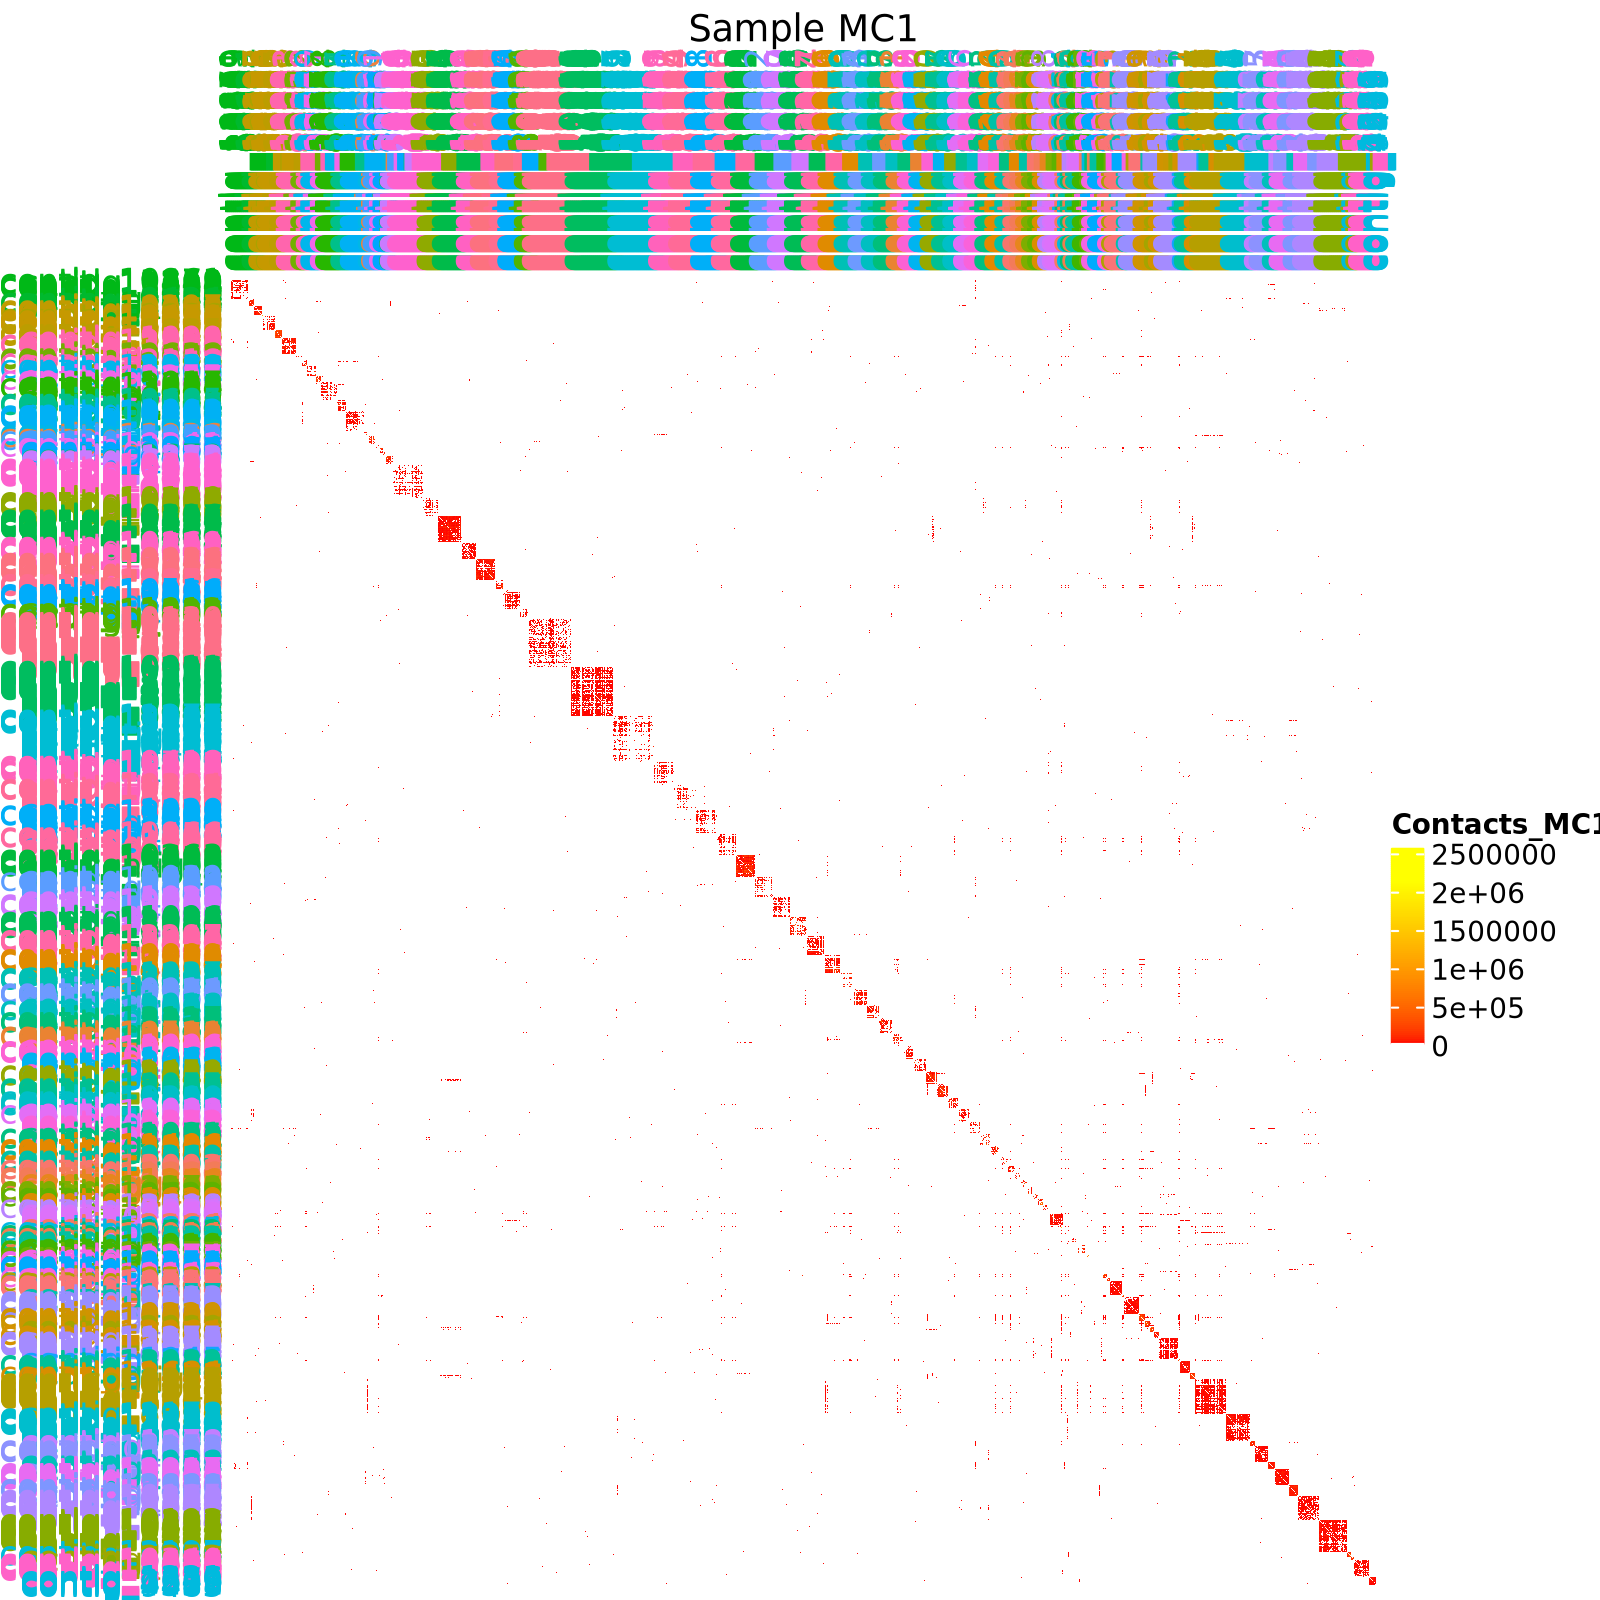

In [38]:
p.dims(8,8)
for (s in samples) {
  message("Plotting sample: ", s)
  mat <- make_heatmap_matrix(heatmaps_below_threshold[[s]], orders[[s]])
  min_nonzero <- get_min_nonzero(mat)
  
  # Get contig-to-bin mapping for this sample
  contigs <- orders[[s]]
  contig_bins <- bins %>%
    filter(contig %in% contigs)

  # Assign a color to each bin
  bin_colors <- setNames(
    scales::hue_pal()(length(unique(contig_bins$bin))),
    unique(contig_bins$bin)
  )

  # Create a named vector: contig -> color (by its bin)
  contig_colors <- setNames(
    bin_colors[contig_bins$bin],
    contig_bins$contig
  )

  # Filter to only contigs in the matrix (just to be safe)
  contig_colors <- contig_colors[intersect(names(contig_colors), rownames(mat))]

  # Build the heatmap
  ht <- Heatmap(
    mat,
    name = paste0("Contacts_", s),
    col = colorRamp2(
      c(0, get_min_nonzero(mat), max(mat)),
      c("white", "red", "yellow")
    ),
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    row_names_side = "left",
    column_names_side = "top",
    column_title = paste("Sample", s),
    row_names_gp = gpar(col = contig_colors[rownames(mat)]),
    column_names_gp = gpar(col = contig_colors[colnames(mat)])
  )

  grid.newpage()
  draw(ht)
}

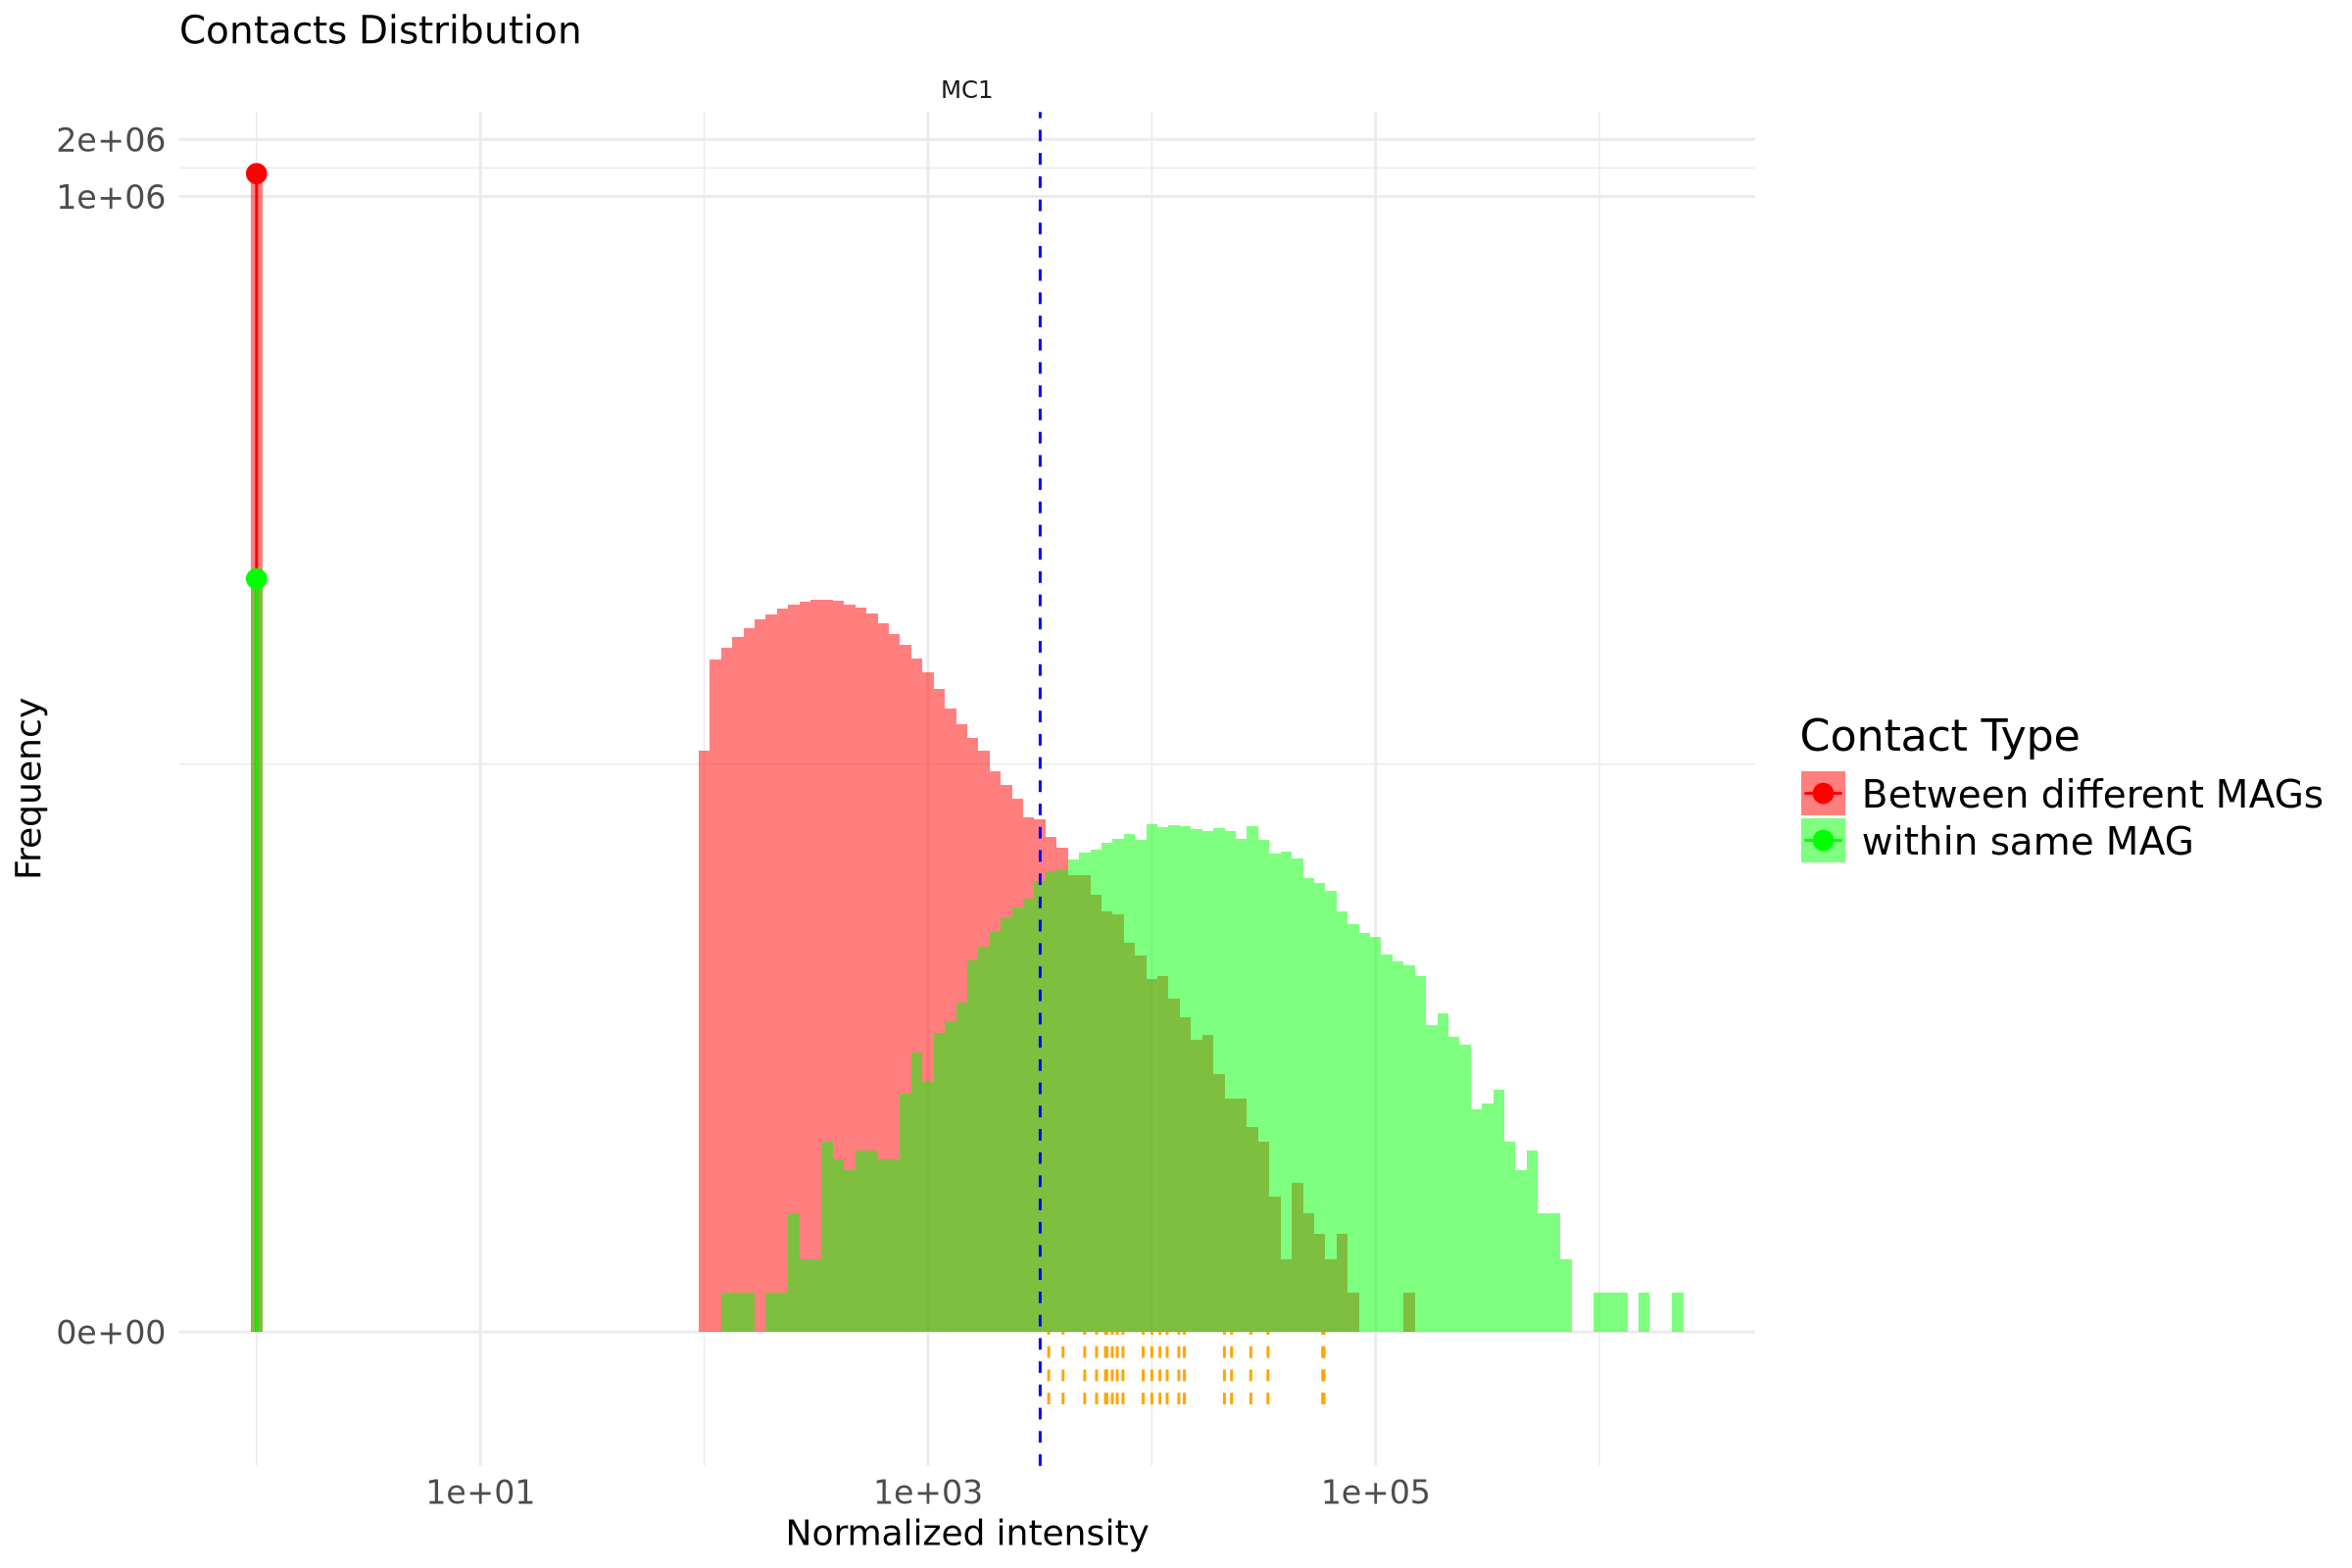

In [39]:
lollipop_data <- combined_contacts %>%
  mutate(contacts_shifted = contacts + 1,
         binned_contacts = floor(contacts_shifted / 0.1) * 0.1) %>%  # Apply binning
  group_by(Contact_Type, binned_contacts) %>%
  summarise(freq = n(), .groups = "drop")  # Count occurrences
# Separate data
zero_freq_data <- lollipop_data %>% filter(binned_contacts == 1)

p.dims(12,8)
ggplot() +
  # Histogram for non-zero values
  geom_histogram(data = combined_contacts, aes(x = contacts + 1, fill = Contact_Type),
                 binwidth = 0.05, alpha = 0.5, position = "identity") +
  # Lollipop-style representation for zero values
  geom_segment(data = zero_freq_data, aes(x = binned_contacts, xend = binned_contacts, 
                                          y = 0, yend = freq, color = Contact_Type), linewidth = 0.5) +
  geom_point(data = zero_freq_data, aes(x = binned_contacts, y = freq, color = Contact_Type), size = 3) +
  # Axes and labels
  scale_x_continuous(trans = "log10") +
  scale_y_continuous(trans = pseudo_log_trans(base = 10)) +
  labs(title = "Contacts Distribution",
       x = "Normalized intensity",
       y = "Frequency") +
  # Facet by sample
  facet_wrap(~ sample, scales = "free") +
  # Colors
  scale_fill_manual(values = c("within same MAG" = "green", "Between different MAGs" = "red"),
                    name = "Contact Type") +
  scale_color_manual(values = c("within same MAG" = "green", "Between different MAGs" = "red"),
                     name = "Contact Type") +
  # Threshold line
  geom_vline(data = threshold_df, aes(xintercept = threshold + 1), color = "blue", linetype = "dashed") +
  geom_segment(data = final_data_circular$MC1, aes(x = median_contacts, xend = median_contacts, y = -2, yend = 0), color = "orange", linetype = "dashed") +
   theme_minimal() +
  theme(
    axis.text = element_text(size = 12),      # tick labels
    axis.title = element_text(size = 13),     # x and y axis labels
    plot.title = element_text(size = 14),
    legend.text = element_text(size = 14),   # legend labels
    legend.title = element_text(size = 16)       # main plot title
  )